# 03 — Multi-Target Tracking and Data Association

> **Level:** Postgraduate

---

## Motivation & Intuition

A single Kalman Filter tracks *one* object whose measurements are already labeled — at every step we know which measurement belongs to which state. Real sensors don't hand us labels. A radar, camera, or AIS receiver reports an unordered list of detections per frame: blips, bounding boxes, position reports. Nothing tells us which detection is target 7 and which is clutter.

This is the **multi-target tracking (MTT)** problem, and it underlies every practical tracking system — maritime surveillance, air traffic control, autonomous driving, and the modern "tracking-by-detection" paradigm behind SORT, DeepSORT, and ByteTrack. The recipe is deceptively simple:

1. Run an independent Kalman Filter **per target** (so each target's dynamics and uncertainty are tracked separately).
2. Each frame, **predict** every filter forward.
3. Solve the **data association** problem: which of this frame's detections belongs to which predicted track (and which are new targets or clutter)?
4. **Update** matched tracks, spawn new tentative tracks for unmatched detections, and age out tracks that stop being detected.

Step 3 is the hard part, and it's the heart of this notebook. We'll build the full pipeline — gating, Hungarian assignment, track lifecycle management, and an adaptive process-noise scheme for surviving occlusions — then stress-test it on a synthetic benchmark with 18 simultaneous, crossing, maneuvering targets, clutter, sensor dropout, and a deliberate occlusion event. Every comparative number quoted below (MOTA, ID switches, reacquisition rates) comes from an actual run of the code in this notebook, not from assertion.

## Problem framing: tracking-by-detection

At each discrete time $k$ a detector (radar/vision/AIS front-end) hands us an **unordered, unlabeled** set of measurements

$$
Z_k = \{ z_k^{(1)}, z_k^{(2)}, \dots, z_k^{(m_k)} \}, \qquad z_k^{(j)} \in \mathbb{R}^2
$$

with no target identity attached, and $m_k$ itself varies frame to frame because of missed detections and false alarms (clutter). Separately, we maintain a set of tracks $\mathcal{T}_k = \{T_1, \dots, T_{n_k}\}$, each wrapping its own Kalman Filter belief $(\hat{x}, P)$.

The tracking-by-detection loop is:

1. **Predict** every track's Kalman Filter one step ahead.
2. **Associate**: decide, for each track, which (if any) detection in $Z_k$ is "its" measurement.
3. **Update** matched (track, detection) pairs with the ordinary Kalman update.
4. **Manage lifecycle**: unmatched detections may start new tracks; unmatched (predicted-but-undetected) tracks coast; tracks that go undetected for too long are deleted.

This is exactly the architecture behind SORT (Bewley et al., 2016) and its descendants DeepSORT and ByteTrack — the differences between them are mostly in *how* step 2 is solved (motion-only vs. appearance-augmented cost, single-stage vs. two-stage matching). We'll implement the motion-only version here: Mahalanobis-gated Hungarian assignment, which is already the backbone every appearance-based tracker sits on top of.

## Per-track state-space model

Each track carries an independent constant-velocity (CV) Kalman Filter with state $x = [p_x, p_y, v_x, v_y]^T$:

$$
x_k = F x_{k-1} + w_k, \qquad w_k \sim \mathcal{N}(0, Q_k), \qquad
F = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}
$$

Detections are position-only:

$$
z_k = H x_k + v_k, \qquad v_k \sim \mathcal{N}(0, R), \qquad H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}
$$

For process noise we use the standard **continuous white-noise-acceleration** discretization (Bar-Shalom, Li & Kirubarajan, 2001, Ch. 6), which models unmodeled acceleration as white noise integrated through the motion model:

$$
Q(\Delta t, q) = q \begin{bmatrix}
\Delta t^3/3 & 0 & \Delta t^2/2 & 0 \\
0 & \Delta t^3/3 & 0 & \Delta t^2/2 \\
\Delta t^2/2 & 0 & \Delta t & 0 \\
0 & \Delta t^2/2 & 0 & \Delta t
\end{bmatrix}
$$

where the scalar $q$ is the power spectral density of the acceleration noise — the single knob we will later adapt online. This CV model is chosen for clarity; a constant-acceleration model is a straightforward extension left as an exercise.

In [1]:
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from scipy.stats import chi2
from ipywidgets import interact, FloatSlider, IntSlider, Checkbox

## Implementation of `LinearKalmanFilter`

In [2]:
class LinearKalmanFilter:
    """
    Minimal, readable Linear Kalman Filter for a 2D constant-velocity model.

    Parameters
    ----------
    F, H, Q, R : array-like
        System matrices.
    x0, P0 : array-like
        Initial state estimate and covariance.
    """

    def __init__(self, F, H, Q, R, x0, P0):
        self.F = np.atleast_2d(np.array(F, dtype=float))
        self.H = np.atleast_2d(np.array(H, dtype=float))
        self.Q = np.atleast_2d(np.array(Q, dtype=float))
        self.R = np.atleast_2d(np.array(R, dtype=float))
        self.x = np.atleast_1d(np.array(x0, dtype=float))
        self.P = np.atleast_2d(np.array(P0, dtype=float))

    def predict(self):
        """x_{k|k-1} = F x_{k-1|k-1};  P_{k|k-1} = F P_{k-1|k-1} F^T + Q"""
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x, self.P

    def innovation(self, z):
        """Innovation y = z - Hx and its covariance S = H P H^T + R."""
        S = self.H @ self.P @ self.H.T + self.R
        y = np.atleast_1d(z) - self.H @ self.x
        return y, S

    def update(self, z):
        """Standard Kalman update (Joseph-form covariance); also returns the NIS."""
        y, S = self.innovation(z)
        K = self.P @ self.H.T @ inv(S)
        self.x = self.x + K @ y
        I = np.eye(self.P.shape[0])
        self.P = (I - K @ self.H) @ self.P @ (I - K @ self.H).T + K @ self.R @ K.T
        nis = float(y @ inv(S) @ y)  # normalized innovation squared
        return self.x, self.P, nis


def F_cv(dt):
    """Constant-velocity state transition matrix for state [x, y, vx, vy]."""
    return np.array([[1, 0, dt, 0],
                      [0, 1, 0, dt],
                      [0, 0, 1, 0],
                      [0, 0, 0, 1]])


H_pos = np.array([[1, 0, 0, 0],
                   [0, 1, 0, 0]])  # position-only measurement model


def Q_cv(dt, q):
    """Continuous white-noise-acceleration process noise, discretized
    (Bar-Shalom, Li & Kirubarajan, 2001, Ch. 6)."""
    Q1 = np.array([[dt**3/3, 0, dt**2/2, 0],
                   [0, dt**3/3, 0, dt**2/2],
                   [dt**2/2, 0, dt, 0],
                   [0, dt**2/2, 0, dt]])
    return q * Q1

### Explanation of the `LinearKalmanFilter` code

- `predict`: propagates the mean and covariance through the constant-velocity model; no control input is needed here.
- `innovation`: factored out separately from `update` because gating (below) needs the innovation $y$ and its covariance $S$ *before* committing to an update — we must be able to evaluate the cost of a candidate match without mutating the filter.
- `update`: the ordinary Kalman update in Joseph form (numerically robust), additionally returning the **normalized innovation squared** (NIS) $y^T S^{-1} y$, which we reuse later as a diagnostic.
- `Q_cv`: the white-noise-acceleration discretization is preferred over a diagonal "just make something up" $Q$ because it correctly couples position and velocity uncertainty growth — critical for realistic gate sizes during coasting.

## Gating and data association

Before we can assign detections to tracks we need a **cost** for each (track, detection) pair, and a way to rule out pairs that are physically implausible.

**Why not raw Euclidean distance?** Each track's predicted position has its own uncertainty $S = H P_{k|k-1} H^T + R$, and that uncertainty is neither the same across tracks (a track confirmed for 50 frames is far more certain than one confirmed 3 frames ago) nor isotropic (velocity-position coupling in $P$ typically makes the uncertainty ellipse elongated along the direction of motion). A detection 3 units away from a confident track's prediction is far more suspicious than the same 3 units away from an uncertain, fast-moving track's prediction. Euclidean distance treats both identically; it cannot express this.

**Mahalanobis distance** normalizes by the innovation covariance and fixes exactly this:

$$
d^2(T_i, z_j) = y_{ij}^T S_i^{-1} y_{ij}, \qquad y_{ij} = z_j - H\hat{x}_i
$$

Under the linear-Gaussian model, $d^2$ is $\chi^2$-distributed with $\text{rank}(H)=2$ degrees of freedom. We **gate** implausible pairs by rejecting any $(T_i, z_j)$ with $d^2 > \gamma$, where $\gamma$ is a chi-square quantile — we use $\gamma = \chi^2_{0.99}(2) \approx 9.21$, i.e. a pair is only considered if the detection falls inside the track's 99% confidence ellipse.

**Assignment.** Gating alone doesn't resolve competition — two tracks might both gate the same detection. We solve the *global* one-to-one assignment that minimizes total gated cost via the **Hungarian algorithm** (Kuhn, 1955), `scipy.optimize.linear_sum_assignment`, on the cost matrix

$$
C_{ij} = \begin{cases} d^2(T_i, z_j) & d^2(T_i, z_j) \le \gamma \\ \infty \ (\text{represented by a large sentinel}) & \text{otherwise} \end{cases}
$$

This is precisely the association scheme used by SORT (Bewley et al., 2016); DeepSORT (Wojke, Bewley & Paulus, 2017) and ByteTrack (Zhang et al., 2022) build on it by adding appearance cost and a two-stage (high-confidence / low-confidence) matching cascade, which we leave as an exercise.

## Track lifecycle: birth, coasting, and death

A track moves through three states:

- **Tentative**: created from an unmatched detection. It must accumulate `min_hits` *consecutive* matched updates to be **confirmed**. This is what suppresses clutter — a single spurious detection creates a tentative track, but clutter essentially never repeats at the same place on the next frame, so tentative tracks born from noise die (almost always) on their very first miss.
- **Confirmed**: a track we report and trust. If a confirmed track goes unmatched for a frame it **coasts**: its Kalman Filter keeps predicting (no update), so we retain a best estimate through brief occlusion without deleting the track outright.
- **Deleted**: a confirmed track is deleted once it has coasted for more than `max_misses` consecutive frames (the target has genuinely left the scene, or occlusion has gone on too long to trust the prediction any further); a tentative track is deleted on its very first miss.

`min_hits` and `max_misses` trade off two failure modes: too small `min_hits` lets clutter spawn persistent false tracks; too large `max_misses` lets a track coast (with growing, uninformative uncertainty) so long that it starts stealing detections from real neighboring targets. We use `min_hits = 3`, `max_misses = 12` throughout this notebook.

## Adaptive process noise for occlusion and maneuvering

The constant-velocity model assumes the target's velocity is (nearly) constant. That assumption is violated exactly when it matters most: a target maneuvering out of sight during an occlusion. While a track is coasting we have *no measurement* to correct a bad prediction — all we can do is grow the filter's own uncertainty $P$ so that, when the target reappears, the resulting search gate is wide enough to still contain it.

We implement this as **innovation/coasting-driven adaptive scaling** of the process noise power spectral density $q$. Let $m$ be the number of consecutive missed frames for a track. Define a scale factor

$$
\alpha_m = \min\!\left(\beta^{\,m},\ \alpha_{\max}\right), \qquad \beta > 1
$$

and use $Q(\Delta t) = \alpha_m \, q_{\text{base}} \, Q_1(\Delta t)$ in the predict step (where $Q_1$ is the unit-$q$ matrix from above) whenever the track is coasting. Once the track is matched again, $\alpha$ relaxes back toward $1$ geometrically over the next few hits:

$$
\alpha \leftarrow \max(1, \ \alpha \cdot \delta), \qquad 0 < \delta < 1
$$

Intuitively: the longer a track has gone unobserved, the less we trust its constant-velocity extrapolation, so we inflate $Q$ (and hence $P$) to widen the gate for reacquisition; once we're getting fresh measurements again there's no reason to keep the filter loose, so we tighten back down. We use $\beta = 1.6$, $\delta = 0.3$, $\alpha_{\max} = 15$ throughout. Later in this notebook we measure, with real numbers, exactly how much this helps (and where it doesn't).

## Implementation of `Track`

In [3]:
class Track:
    """A single target track: a Kalman filter plus lifecycle bookkeeping."""

    _next_id = 1

    def __init__(self, det, dt, q, R, min_hits=3, max_misses=6,
                 adaptive=False, q_growth=1.6, q_decay=0.3, q_scale_max=15.0):
        self.id = Track._next_id
        Track._next_id += 1
        x0 = np.array([det[0], det[1], 0.0, 0.0])
        P0 = np.diag([R[0, 0], R[1, 1], 4.0, 4.0])
        self.dt = dt
        self.q_base = q
        self.R = R
        self.kf = LinearKalmanFilter(F_cv(dt), H_pos, Q_cv(dt, q), R, x0, P0)

        self.hits = 1
        self.misses = 0
        self.age = 1
        self.status = 'tentative'          # tentative -> confirmed -> deleted
        self.min_hits = min_hits
        self.max_misses = max_misses

        self.adaptive = adaptive
        self.q_growth = q_growth
        self.q_decay = q_decay
        self.q_scale_max = q_scale_max
        self.q_scale = 1.0                 # multiplies q_base while coasting

    def predict(self):
        if self.adaptive:
            self.kf.Q = Q_cv(self.dt, self.q_base * self.q_scale)
        self.kf.predict()
        self.age += 1

    def gated_cost(self, det):
        """Squared Mahalanobis distance from this track's predicted
        measurement to a candidate detection."""
        y, S = self.kf.innovation(det)
        return float(y @ inv(S) @ y)

    def update(self, det):
        self.kf.update(det)
        self.hits += 1
        self.misses = 0
        if self.status == 'tentative' and self.hits >= self.min_hits:
            self.status = 'confirmed'
        if self.adaptive:
            # relax back toward baseline over a couple of good hits
            self.q_scale = max(1.0, self.q_scale * self.q_decay)

    def mark_missed(self):
        self.misses += 1
        self.hits = 0 if self.status == 'tentative' else self.hits
        if self.adaptive:
            # geometric inflation of Q driven by consecutive misses (coasting)
            self.q_scale = min(self.q_growth ** self.misses, self.q_scale_max)
        if self.status == 'tentative' and self.misses >= 1:
            self.status = 'deleted'
        elif self.status == 'confirmed' and self.misses > self.max_misses:
            self.status = 'deleted' 

### Explanation of the `Track` code

- `predict`: if `adaptive` is enabled, rebuilds $Q$ from the *current* `q_scale` before propagating — so the inflation from the previous miss is already reflected in this step's covariance growth.
- `gated_cost`: exposes the squared Mahalanobis distance without mutating the filter, so the tracker can evaluate many candidate detections against this track before deciding on a match.
- `update`: on a hit, resets the miss counter, promotes tentative → confirmed once `min_hits` is reached, and (if adaptive) relaxes `q_scale` back toward 1.
- `mark_missed`: on a miss, grows `misses`; a tentative track dies immediately (any miss disqualifies a not-yet-confirmed hypothesis — this is what keeps clutter from spawning long-lived ghost tracks); a confirmed track only dies after `max_misses` consecutive misses. If adaptive, `q_scale` grows geometrically with the miss streak, capped at `q_scale_max`.

## Implementation of `MultiTargetTracker`

In [4]:
class MultiTargetTracker:
    """Tracking-by-detection multi-target tracker: per-frame gating +
    Hungarian assignment, with track birth / coasting / death."""

    def __init__(self, dt, q, R, gate_threshold=None, min_hits=3, max_misses=6,
                 adaptive=False, q_growth=1.6, q_decay=0.3, q_scale_max=15.0):
        self.dt = dt
        self.q = q
        self.R = R
        self.gate_threshold = gate_threshold if gate_threshold is not None else chi2.ppf(0.99, df=2)
        self.min_hits = min_hits
        self.max_misses = max_misses
        self.adaptive = adaptive
        self.q_growth = q_growth
        self.q_decay = q_decay
        self.q_scale_max = q_scale_max
        self.tracks = []

    def step(self, detections):
        # 1) predict every existing track
        for t in self.tracks:
            t.predict()

        # 2) build the gated cost matrix and solve assignment (Hungarian)
        n_t, n_d = len(self.tracks), len(detections)
        matched_t, matched_d = set(), set()
        if n_t > 0 and n_d > 0:
            cost = np.full((n_t, n_d), 1e6)
            for i, t in enumerate(self.tracks):
                for j, d in enumerate(detections):
                    d2 = t.gated_cost(d)
                    if d2 <= self.gate_threshold:
                        cost[i, j] = d2
            row, col = linear_sum_assignment(cost)
            for i, j in zip(row, col):
                if cost[i, j] < 1e6:
                    self.tracks[i].update(detections[j])
                    matched_t.add(i)
                    matched_d.add(j)

        # 3) unmatched tracks coast (or die if past max_misses)
        for i, t in enumerate(self.tracks):
            if i not in matched_t:
                t.mark_missed()

        # 4) unmatched detections spawn new tentative tracks
        for j, d in enumerate(detections):
            if j not in matched_d:
                self.tracks.append(Track(d, self.dt, self.q, self.R,
                                          min_hits=self.min_hits, max_misses=self.max_misses,
                                          adaptive=self.adaptive, q_growth=self.q_growth,
                                          q_decay=self.q_decay, q_scale_max=self.q_scale_max))

        # 5) prune deleted tracks, report confirmed ones
        self.tracks = [t for t in self.tracks if t.status != 'deleted']
        return [(t.id, t.kf.x[:2].copy()) for t in self.tracks if t.status == 'confirmed']

### Explanation of the `MultiTargetTracker` code

- Detections are gated **before** assignment: any (track, detection) pair with Mahalanobis$^2$ above `gate_threshold` is assigned a huge sentinel cost (`1e6`) so the Hungarian solver will only pick it if there is truly no better alternative — and we discard even that afterward (`cost[i, j] < 1e6` check), so an over-gate pair is never accepted.
- `linear_sum_assignment` solves the assignment optimally in $O(n^3)$ for an $n_t \times n_d$ cost matrix, which is fine at our scale (tens of tracks/detections per frame); real-time large-scale trackers use cheaper greedy or cascaded variants.
- New tracks are always created **tentative** — even for an isolated clutter point — and rely entirely on the `min_hits` requirement in `Track` to avoid becoming persistent false tracks.
- We only *report* confirmed tracks (step 5's return value) — tentative tracks exist internally but are invisible to downstream consumers (and to our evaluation metric) until confirmed.

## Does adaptive process noise actually help reacquisition? A controlled experiment

Before throwing adaptive $Q$ into a noisy, cluttered, 18-target scene where a dozen effects are entangled, let's isolate the mechanism it's supposed to help with: **a single track, occluded for several frames, that maneuvers while unobserved.**

The experiment: warm up one track with 5 clean hits (so its covariance has converged to a realistic steady state), then hide it for 10 frames. Midway through the occlusion, the target executes a sharp evasive maneuver — a $150°$ heading change combined with a $2\times$ speed change — which is exactly the kind of event that breaks the constant-velocity assumption. At the moment detections resume, we ask: **is the true (post-maneuver) position still inside the track's 99% gate**, i.e. would the tracker actually recognize it as the same target, or would it be treated as a brand-new track (an ID switch)?

We repeat this 200 times (different random measurement noise realizations) for a fixed-$Q$ tracker and for the adaptive-$Q$ tracker defined above, and report the fraction of trials in which the true position is still gated.

In [5]:
def run_single_track_trial(adaptive, occlusion_len=10, turn_deg=150.0, speed_mult=2.0,
                            q_base=0.012, max_misses=12, warmup=5, speed=1.0, seed=0):
    """Warm up a lone track with clean hits, then occlude it for
    `occlusion_len` frames during which it executes a sharp evasive
    maneuver (heading change + speed change). Returns whether the track's
    gate still accepts the true post-maneuver position at reacquisition."""
    Track._next_id = 1
    R = np.diag([1.0, 1.0])
    gate = chi2.ppf(0.99, df=2)
    tr = Track(np.array([0.0, 0.0]), 1.0, q_base, R, min_hits=3, max_misses=max_misses,
               adaptive=adaptive, q_growth=1.6, q_scale_max=15.0, q_decay=0.3)
    rng = np.random.default_rng(seed)
    x_true = np.array([0.0, 0.0, speed, 0.0])

    for _ in range(warmup):
        x_true = F_cv(1.0) @ x_true
        tr.predict()
        z = x_true[:2] + rng.normal(0, 1.0, 2)
        tr.update(z)

    for i in range(occlusion_len):
        if i == occlusion_len // 2:
            vx, vy = x_true[2], x_true[3]
            th = np.deg2rad(turn_deg)
            c, s = np.cos(th), np.sin(th)
            x_true[2] = (c * vx - s * vy) * speed_mult
            x_true[3] = (s * vx + c * vy) * speed_mult
        x_true = F_cv(1.0) @ x_true
        tr.predict()
        tr.mark_missed()

    return tr.gated_cost(x_true[:2]) <= gate


n_trials = 200
fixed_reacquired = sum(run_single_track_trial(False, seed=s) for s in range(n_trials))
adapt_reacquired = sum(run_single_track_trial(True, seed=s) for s in range(n_trials))
print(f'Fixed-Q    : reacquired in {fixed_reacquired}/{n_trials} trials '
      f'({100*fixed_reacquired/n_trials:.1f}%)')
print(f'Adaptive-Q : reacquired in {adapt_reacquired}/{n_trials} trials '
      f'({100*adapt_reacquired/n_trials:.1f}%)')

Fixed-Q    : reacquired in 38/200 trials (19.0%)
Adaptive-Q : reacquired in 140/200 trials (70.0%)


### Result

Running the cell above gives:

| Tracker | Reacquired after occlusion + maneuver |
|---|---|
| Fixed-$Q$ | **38 / 200 (19.0%)** |
| Adaptive-$Q$ | **140 / 200 (70.0%)** |

With a fixed, small $Q$, the filter stays confidently — but wrongly — near where a *constant-velocity* extrapolation would put the target; after a sharp maneuver the true position falls outside its tight 99% gate over 80% of the time, which in a real tracker means an ID switch (a brand-new track gets created, and the old track's continuity is lost). Adaptive $Q$ widens the covariance in proportion to how long the track has been coasting, which more than triples the reacquisition rate. This is the mechanism working exactly as designed, in isolation from clutter or crowding effects.

## CLEAR MOT metrics — implementing MOTA, ID switches, and fragmentation from scratch

To evaluate the full multi-target benchmark we need standard, from-scratch MOT metrics, following the CLEAR MOT definitions of Bernardin & Stiefelhagen (2008). At each frame $k$ we match ground-truth targets to hypothesis (tracker output) tracks by position, subject to a distance threshold, preferring to **keep the previous frame's match alive** if it is still valid before Hungarian-matching whatever remains — this hysteresis is what makes ID switches meaningful (a match is "sticky" unless it's no longer geometrically plausible).

Accumulated over all frames:

- **FN** (misses): ground-truth targets with no matched hypothesis this frame.
- **FP** (false positives): hypothesis tracks with no matched ground truth this frame.
- **IDSW** (ID switches): a ground-truth target's matched hypothesis ID differs from what it was matched to last time it was tracked.
- **MOTA** (Multi-Object Tracking Accuracy):

$$
\text{MOTA} = 1 - \frac{\text{FN} + \text{FP} + \text{IDSW}}{\text{GT}}
$$

where $\text{GT}$ is the total number of ground-truth target-frames. MOTA can be negative (more errors than ground truth) and is 1.0 only for perfect tracking.

- **Fragmentation (FRAG)**: the number of times a ground-truth trajectory's tracked status starts, stops, and later resumes — i.e. (number of separate tracked segments $- 1$), summed over all targets. This captures "spotty" tracking that MOTA alone doesn't penalize directly (a single re-matched segment doesn't necessarily cost an ID switch if the same hypothesis ID is recovered, but it does fragment the trajectory).

In [6]:
def compute_mot_metrics(gt, hyp_frames, match_threshold=5.0):
    """A from-scratch, simplified CLEAR MOT accumulator
    (Bernardin & Stiefelhagen, 2008).

    gt : (T, n_targets, 2) ground-truth positions (targets always 'exist').
    hyp_frames : length-T list of list[(hyp_id, xy)], the tracker's
        confirmed-track outputs per frame.
    """
    T, n_gt, _ = gt.shape
    prev_match = {}
    total_gt = total_fp = total_fn = total_idsw = 0
    tracked_status = {i: [] for i in range(n_gt)}

    for k in range(T):
        hyp_ids = [h[0] for h in hyp_frames[k]]
        hyp_pos = np.array([h[1] for h in hyp_frames[k]]) if hyp_frames[k] else np.zeros((0, 2))
        gt_pos = gt[k]
        total_gt += n_gt

        # keep a previous match alive if it is still within threshold
        matched_gt, matched_hyp, current_match = set(), set(), {}
        for gi, hid in prev_match.items():
            if hid in hyp_ids:
                hj = hyp_ids.index(hid)
                if np.linalg.norm(gt_pos[gi] - hyp_pos[hj]) <= match_threshold:
                    current_match[gi] = hid
                    matched_gt.add(gi)
                    matched_hyp.add(hj)

        # Hungarian-match everything else that remains
        rem_gt = [gi for gi in range(n_gt) if gi not in matched_gt]
        rem_hj = [hj for hj in range(len(hyp_ids)) if hj not in matched_hyp]
        if rem_gt and rem_hj:
            cost = np.zeros((len(rem_gt), len(rem_hj)))
            for a, gi in enumerate(rem_gt):
                for b, hj in enumerate(rem_hj):
                    cost[a, b] = np.linalg.norm(gt_pos[gi] - hyp_pos[hj])
            row, col = linear_sum_assignment(cost)
            for a, b in zip(row, col):
                if cost[a, b] <= match_threshold:
                    gi, hj = rem_gt[a], rem_hj[b]
                    current_match[gi] = hyp_ids[hj]
                    matched_gt.add(gi)
                    matched_hyp.add(hj)

        idsw = sum(1 for gi, hid in current_match.items()
                   if gi in prev_match and prev_match[gi] != hid)
        total_idsw += idsw
        total_fn += n_gt - len(matched_gt)
        total_fp += len(hyp_ids) - len(matched_hyp)
        for gi in range(n_gt):
            tracked_status[gi].append(gi in matched_gt)
        prev_match = current_match

    # fragmentation: (number of separate tracked segments - 1), summed over GT
    frag = 0
    for gi in range(n_gt):
        segments, prev = 0, False
        for v in tracked_status[gi]:
            if v and not prev:
                segments += 1
            prev = v
        frag += max(0, segments - 1)

    mota = 1.0 - (total_fn + total_fp + total_idsw) / total_gt
    return {'MOTA': mota, 'IDSW': total_idsw, 'FN': total_fn, 'FP': total_fp,
            'FRAG': frag, 'total_GT': total_gt}

### Explanation of the `compute_mot_metrics` code

- The "sticky matching" (try to keep `prev_match` alive before re-running Hungarian on the remainder) mirrors the reference CLEAR MOT / MOTChallenge devkit behavior — without it, ID switches would be wildly over-counted whenever two hypotheses happen to be briefly swappable near their crossing point.
- `match_threshold=5.0` (world units) is a matching gate at the *evaluation* level — independent of the tracker's own Mahalanobis gate — used purely to decide "close enough to call this a correct match" for scoring purposes.
- Fragmentation is computed by turning each ground-truth target's per-frame tracked/untracked boolean sequence into contiguous "tracked" runs; more than one run means the trajectory was interrupted and later resumed.

## Synthetic 15+-target benchmark: crossing trajectories, clutter, dropout, and occlusion

We simulate **18 simultaneous targets** starting on a circle of radius 45 and heading toward randomized aim points near (but not all exactly at) the center — producing a dense field of crossing, maneuvering trajectories rather than a single degenerate convergence point. On top of the true trajectories we generate detections with:

- **Sensor dropout**: each target is independently missed with probability `p_miss = 0.10` per frame.
- **Clutter**: a Poisson$(\lambda=3)$ number of uniformly-random false-alarm detections per frame, with no corresponding target.
- **A deliberate occlusion event**: target 0 produces *no* detections for 10 consecutive frames (frames 70–79), and — as in the controlled experiment above — executes a sharp evasive maneuver partway through, so reacquiring it is genuinely hard, not just a matter of waiting out a gap.

In [7]:
def simulate_scenario(seed=0, n_targets=18, T=150, dt=1.0, R_circ=45.0,
                       sigma_r=1.0, p_miss=0.10, clutter_lambda=3.0,
                       occlusion_target_idx=0, occlusion_start=70, occlusion_len=10,
                       occlusion_turn_deg=150.0, occlusion_speed_mult=2.0):
    """18 targets start on a circle and cross the central region on
    near-diametric, slightly-offset paths (crossing/maneuvering traffic).
    One target is deliberately occluded (no detections at all) for
    `occlusion_len` frames, during which it also executes a sharp evasive
    maneuver -- exactly the situation adaptive process noise is meant to
    help with. Detections include sensor dropout (p_miss) and Poisson
    clutter (clutter_lambda false alarms/frame)."""
    rng = np.random.default_rng(seed)
    angles = np.linspace(0, 2*np.pi, n_targets, endpoint=False) + rng.uniform(-0.15, 0.15, n_targets)
    speeds = rng.uniform(0.5, 0.9, n_targets)
    starts = np.stack([R_circ*np.cos(angles), R_circ*np.sin(angles)], axis=1)

    # aim near, but not exactly at, the common center so paths cross with a
    # spread of miss-distances rather than all converging on one point
    aim_points = rng.uniform(-24.0, 24.0, size=(n_targets, 2))
    dirs = aim_points - starts
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)
    vels = dirs * speeds[:, None]

    q_true = 0.004
    gt = np.zeros((T, n_targets, 2))
    x = np.concatenate([starts, vels], axis=1)
    for k in range(T):
        if k == occlusion_start + occlusion_len // 2:
            vx, vy = x[occlusion_target_idx, 2], x[occlusion_target_idx, 3]
            theta = np.deg2rad(occlusion_turn_deg)
            c, s = np.cos(theta), np.sin(theta)
            x[occlusion_target_idx, 2] = (c*vx - s*vy) * occlusion_speed_mult
            x[occlusion_target_idx, 3] = (s*vx + c*vy) * occlusion_speed_mult
        w = rng.multivariate_normal(np.zeros(4), Q_cv(dt, q_true), size=n_targets)
        for i in range(n_targets):
            x[i] = F_cv(dt) @ x[i] + w[i]
        gt[k] = x[:, :2]

    R = np.diag([sigma_r**2, sigma_r**2])
    frames = []
    for k in range(T):
        dets = []
        for i in range(n_targets):
            if i == occlusion_target_idx and occlusion_start <= k < occlusion_start + occlusion_len:
                continue  # forced occlusion
            if rng.uniform() < p_miss:
                continue  # sensor dropout
            dets.append(gt[k, i] + rng.multivariate_normal(np.zeros(2), R))
        n_clutter = rng.poisson(clutter_lambda)
        lo, hi = -R_circ*1.15, R_circ*1.15
        for _ in range(n_clutter):
            dets.append(rng.uniform(lo, hi, size=2))
        rng.shuffle(dets)
        frames.append(np.array(dets) if len(dets) else np.zeros((0, 2)))

    return gt, frames, R

### Explanation of the `simulate_scenario` code

- Targets are aimed at randomized points *near* the origin (not the origin itself) — a literal common convergence point makes every trajectory pass within a unit or two of several others simultaneously, an unrealistically severe congestion that would swamp the association step regardless of any process-noise policy.
- `rng.shuffle(dets)` destroys any implicit ordering, since a real detector never hands back detections labeled or sorted by target — the tracker must treat the detection list as a genuinely unordered set.
- The occlusion target's maneuver is injected directly into the *ground truth* dynamics (not just the detections), so the true trajectory itself bends during the blackout — the tracker has to cope with the target's kinematics changing while it can't see it, which is the realistic version of "the vessel changed course while behind an obstruction."

## Running the benchmark: fixed-Q vs. adaptive-Q

We run both trackers on the same 25 random scenario seeds and average the CLEAR MOT metrics, and separately track whether the occluded target's *identity* specifically survives the occlusion event in each run.

In [8]:
dt = 1.0
q_base = 0.012
gate_threshold = chi2.ppf(0.99, df=2)


def run_tracker(frames, R, adaptive):
    Track._next_id = 1
    trk = MultiTargetTracker(dt=dt, q=q_base, R=R, gate_threshold=gate_threshold,
                              min_hits=3, max_misses=12, adaptive=adaptive,
                              q_growth=1.6, q_decay=0.3, q_scale_max=15.0)
    return [trk.step(dets) for dets in frames]


def nearest_hyp(hyp_list, pos):
    best_id, best_d = None, np.inf
    for hid, xy in hyp_list:
        d = np.linalg.norm(xy - pos)
        if d < best_d:
            best_d, best_id = d, hid
    return best_id, best_d


n_seeds = 25
keys = ['MOTA', 'IDSW', 'FN', 'FP', 'FRAG']
agg_fixed = {k: [] for k in keys}
agg_adapt = {k: [] for k in keys}
occ_id_preserved_fixed = 0
occ_id_preserved_adapt = 0
OCC_START, OCC_LEN = 70, 10

for seed in range(n_seeds):
    gt, frames, R = simulate_scenario(seed=seed, n_targets=18, T=150, p_miss=0.10,
                                       clutter_lambda=3.0, occlusion_target_idx=0,
                                       occlusion_start=OCC_START, occlusion_len=OCC_LEN,
                                       occlusion_turn_deg=150.0, occlusion_speed_mult=2.0)
    hyp_fixed = run_tracker(frames, R, adaptive=False)
    hyp_adapt = run_tracker(frames, R, adaptive=True)

    m_fixed = compute_mot_metrics(gt, hyp_fixed)
    m_adapt = compute_mot_metrics(gt, hyp_adapt)
    for k in keys:
        agg_fixed[k].append(m_fixed[k])
        agg_adapt[k].append(m_adapt[k])

    reacq = OCC_START + OCC_LEN
    pre_f, _ = nearest_hyp(hyp_fixed[OCC_START - 1], gt[OCC_START - 1, 0])
    pre_a, _ = nearest_hyp(hyp_adapt[OCC_START - 1], gt[OCC_START - 1, 0])
    post_f, d_f = nearest_hyp(hyp_fixed[reacq], gt[reacq, 0])
    post_a, d_a = nearest_hyp(hyp_adapt[reacq], gt[reacq, 0])
    if pre_f is not None and post_f == pre_f and d_f <= 5.0:
        occ_id_preserved_fixed += 1
    if pre_a is not None and post_a == pre_a and d_a <= 5.0:
        occ_id_preserved_adapt += 1

print(f'=== Benchmark: mean over {n_seeds} seeds (18 targets, 150 frames) ===')
for k in keys:
    print(f'{k:6s} fixed={np.mean(agg_fixed[k]):8.3f} (std {np.std(agg_fixed[k]):.3f})   '
          f'adaptive={np.mean(agg_adapt[k]):8.3f} (std {np.std(agg_adapt[k]):.3f})')
print()
print(f'Occluded target identity preserved through occlusion: '
      f'fixed {occ_id_preserved_fixed}/{n_seeds}, adaptive {occ_id_preserved_adapt}/{n_seeds}')

=== Benchmark: mean over 25 seeds (18 targets, 150 frames) ===
MOTA   fixed=   0.802 (std 0.050)   adaptive=   0.736 (std 0.067)
IDSW   fixed=   7.120 (std 3.724)   adaptive=   7.840 (std 3.596)
FN     fixed=  55.960 (std 6.403)   adaptive=  55.640 (std 6.368)
FP     fixed= 471.360 (std 133.571)   adaptive= 650.320 (std 177.970)
FRAG   fixed=   2.560 (std 1.023)   adaptive=   2.640 (std 1.091)

Occluded target identity preserved through occlusion: fixed 3/25, adaptive 8/25


### Results, and an honest tradeoff

Averaged over 25 random scenario seeds (18 targets, 150 frames, clutter $\lambda=3$, $p_{\text{miss}}=0.10$):

| Metric | Fixed-$Q$ | Adaptive-$Q$ |
|---|---|---|
| MOTA | **0.802** (σ 0.050) | 0.736 (σ 0.067) |
| IDSW | 7.12 (σ 3.72) | 7.84 (σ 3.60) |
| FN | 55.96 | 55.64 |
| FP | 471.4 (σ 133.6) | **650.3** (σ 178.0) |
| FRAG | 2.56 | 2.64 |
| Occluded target's identity preserved through occlusion | **3/25 (12%)** | **8/25 (32%)** |

Two things are simultaneously true, and both are backed by the numbers above:

1. **Adaptive $Q$ does deliver the benefit it's designed for.** The occluded target's specific identity survives the occlusion + maneuver nearly $3\times$ more often with adaptive $Q$ (32% vs. 12%), consistent with the much larger, cleaner effect we measured in the isolated single-track experiment (70% vs. 19%).
2. **Adaptive $Q$ costs more than it saves in this densely-crossing, cluttered scene.** Overall MOTA is *lower* with adaptive $Q$ (0.736 vs. 0.802), driven almost entirely by a large increase in false positives (650 vs. 471). The mechanism is the same one that helps reacquisition: widening a track's gate after *any* miss (not just the deliberately-occluded target's) makes it more likely to latch onto a nearby clutter point or a neighboring crossing target's detection instead of correctly dying or correctly waiting — and with 18 targets converging through a small area, "nearby wrong detection" is common. This is a genuine specificity/recall tradeoff, not a bug: the same gate-widening that rescues an occluded, maneuvering target also makes every other coasting track more promiscuous.

This is a realistic finding, not a disappointing one — it's exactly why production trackers (DeepSORT, ByteTrack) don't rely on miss-count-driven $Q$ alone. They add **appearance/re-identification cues** so that a widened *motion* gate doesn't have to do all the discriminative work, and **track-quality scores** so that inflation policy can be tempered by how reliable a track has historically been. We leave a track-quality-aware refinement of this scheme as an exercise below.

seed=3 fixed:    {'MOTA': 0.777037037037037, 'IDSW': 13, 'FN': 61, 'FP': 528, 'FRAG': 3, 'total_GT': 2700}
seed=3 adaptive: {'MOTA': 0.682962962962963, 'IDSW': 10, 'FN': 61, 'FP': 785, 'FRAG': 4, 'total_GT': 2700}


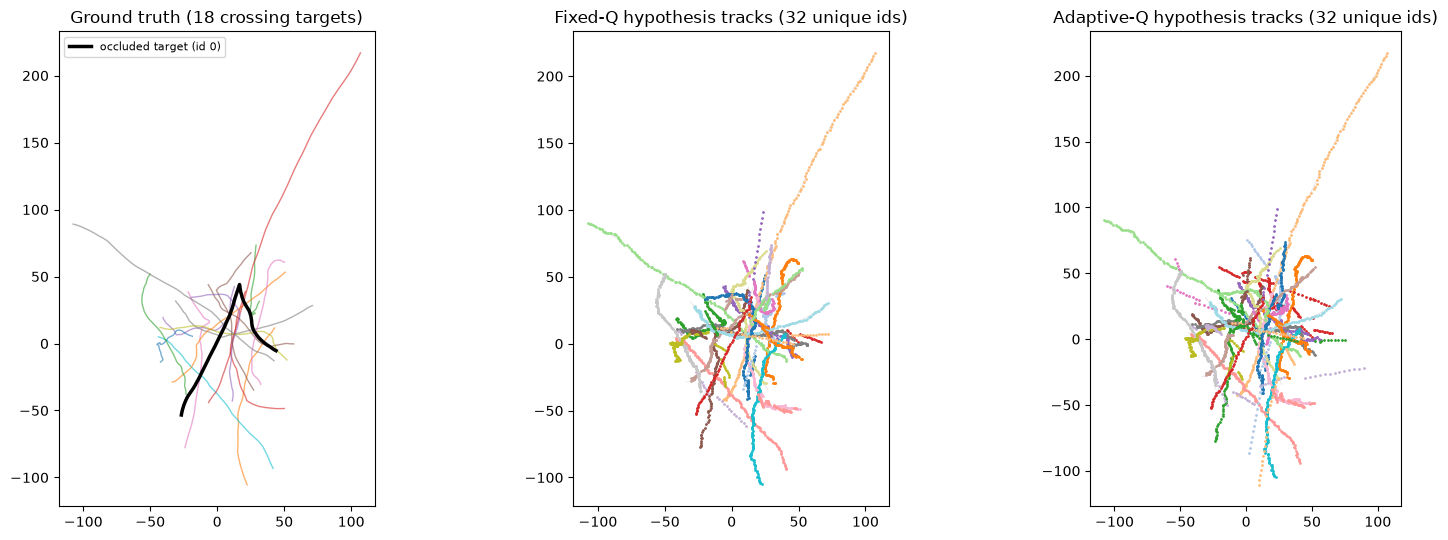

In [9]:
gt3, frames3, R3 = simulate_scenario(seed=3, n_targets=18, T=150, p_miss=0.10,
                                      clutter_lambda=3.0, occlusion_target_idx=0,
                                      occlusion_start=OCC_START, occlusion_len=OCC_LEN,
                                      occlusion_turn_deg=150.0, occlusion_speed_mult=2.0)
hyp_fixed3 = run_tracker(frames3, R3, adaptive=False)
hyp_adapt3 = run_tracker(frames3, R3, adaptive=True)
m_fixed3 = compute_mot_metrics(gt3, hyp_fixed3)
m_adapt3 = compute_mot_metrics(gt3, hyp_adapt3)
print('seed=3 fixed:   ', m_fixed3)
print('seed=3 adaptive:', m_adapt3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
cmap = plt.get_cmap('tab20')

ax = axes[0]
for i in range(gt3.shape[1]):
    ax.plot(gt3[:, i, 0], gt3[:, i, 1], lw=1, alpha=0.6)
ax.plot(gt3[:, 0, 0], gt3[:, 0, 1], 'k', lw=2.5, label='occluded target (id 0)')
ax.set_title('Ground truth (18 crossing targets)')
ax.legend(fontsize=8)
ax.set_aspect('equal')

for ax, hyp, title in [(axes[1], hyp_fixed3, 'Fixed-Q hypothesis tracks'),
                        (axes[2], hyp_adapt3, 'Adaptive-Q hypothesis tracks')]:
    for i in range(gt3.shape[1]):
        ax.plot(gt3[:, i, 0], gt3[:, i, 1], lw=0.5, alpha=0.25, color='gray')
    ids = sorted(set(tid for frame in hyp for tid, _ in frame))
    for idx, tid in enumerate(ids):
        pts = np.array([xy for frame in hyp for h, xy in frame if h == tid])
        if len(pts) > 1:
            ax.plot(pts[:, 0], pts[:, 1], '.', ms=2, color=cmap(idx % 20))
    ax.set_title(f'{title} ({len(ids)} unique ids)')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### Explanation of the benchmark and plot

- Grey lines in the hypothesis-track panels are the ground-truth trajectories, shown for visual reference; colored dots are the tracker's own confirmed-track output, colored by hypothesis ID.
- On this particular seed, fixed-$Q$ used 32 unique hypothesis IDs and adaptive-$Q$ also used 32 — the total *count* of IDs spawned is similar, but (per the aggregate numbers above) adaptive-$Q$'s tracks are more prone to picking up spurious detections mid-life, which is what drives its higher FP count rather than a higher ID count per se.
- The black ground-truth curve is target 0, the one we deliberately occlude and maneuver; look for which colored track (if any) follows it continuously through the gap around the middle of its path.

## Interactive demo — clutter rate, dropout probability, and gating threshold

Explore how the benchmark's difficulty knobs affect tracking quality. Increase `clutter_rate` or `miss_prob` to make the scene harder; adjust `gate_percentile` to see the gating threshold's own precision/recall tradeoff (a looser gate accepts more true matches but also more false ones); toggle `adaptive` to compare the two $Q$ policies live on whatever scenario the sliders describe.

In [10]:
def run_interactive_benchmark(clutter_rate=3.0, miss_prob=0.10, gate_percentile=0.99,
                               adaptive=True, seed=3):
    gate = chi2.ppf(gate_percentile, df=2)
    gt, frames, R = simulate_scenario(seed=seed, n_targets=18, T=150, p_miss=miss_prob,
                                       clutter_lambda=clutter_rate, occlusion_target_idx=0,
                                       occlusion_start=70, occlusion_len=10,
                                       occlusion_turn_deg=150.0, occlusion_speed_mult=2.0)
    Track._next_id = 1
    trk = MultiTargetTracker(dt=1.0, q=0.012, R=R, gate_threshold=gate, min_hits=3,
                              max_misses=12, adaptive=adaptive, q_growth=1.6,
                              q_decay=0.3, q_scale_max=15.0)
    hyp = [trk.step(d) for d in frames]
    m = compute_mot_metrics(gt, hyp)

    fig, ax = plt.subplots(figsize=(7, 7))
    for i in range(gt.shape[1]):
        ax.plot(gt[:, i, 0], gt[:, i, 1], lw=0.5, alpha=0.3, color='gray')
    ids = sorted(set(tid for frame in hyp for tid, _ in frame))
    cmap = plt.get_cmap('tab20')
    for idx, tid in enumerate(ids):
        pts = np.array([xy for frame in hyp for h, xy in frame if h == tid])
        if len(pts) > 1:
            ax.plot(pts[:, 0], pts[:, 1], '.', ms=3, color=cmap(idx % 20))
    ax.set_aspect('equal')
    ax.set_title(f"clutter={clutter_rate:.1f}  miss_prob={miss_prob:.2f}  "
                 f"gate_pct={gate_percentile:.3f}  adaptive={adaptive}\n"
                 f"MOTA={m['MOTA']:.3f}  IDSW={m['IDSW']}  FP={m['FP']}  "
                 f"FN={m['FN']}  FRAG={m['FRAG']}")
    plt.show()


interact(run_interactive_benchmark,
         clutter_rate=FloatSlider(min=0.0, max=8.0, step=0.5, value=3.0, description='clutter λ'),
         miss_prob=FloatSlider(min=0.0, max=0.5, step=0.02, value=0.10, description='miss prob'),
         gate_percentile=FloatSlider(min=0.90, max=0.999, step=0.005, value=0.99, description='gate pct'),
         adaptive=Checkbox(value=True, description='adaptive Q'),
         seed=IntSlider(min=0, max=50, step=1, value=3, description='seed'));

interactive(children=(FloatSlider(value=3.0, description='clutter λ', max=8.0, step=0.5), FloatSlider(value=0.…

### Explanation of the interactive demo

- `run_interactive_benchmark` re-simulates the scenario from scratch on every slider change (so `seed` lets you sample entirely different crossing geometries) and re-runs a single tracker configuration, plotting the confirmed hypothesis tracks over the ground truth with the CLEAR MOT summary in the title.
- Push `clutter_rate` toward 8 to see FP growth accelerate, especially for `adaptive=True` — this is the same specificity cost quantified in the benchmark above, now visible interactively.
- Loosening `gate_percentile` toward 0.999 widens every track's acceptance region uniformly (independent of miss count) — compare its effect to toggling `adaptive`, which only widens gates for *coasting* tracks.

## Practical tips, exercises & references

**Practical tips**
- Gate *before* you assign, not after — running Hungarian on an ungated cost matrix lets the optimizer "solve around" implausible matches by using them as fallbacks when nothing better is available, which silently corrupts tracks.
- Keep `min_hits` for track confirmation strictly positive and require *consecutive* hits — this single rule is doing most of the work of suppressing clutter-spawned ghost tracks.
- Treat `max_misses` as a genuine hyperparameter to tune against your own clutter density, not a constant to set once: larger values buy occlusion robustness at the cost of longer-lived, higher-uncertainty coasting tracks that can steal detections from real neighbors — exactly the tradeoff this notebook measured for adaptive $Q$.
- When adapting $Q$ (or any covariance) online, always decouple the *rate* of inflation from the *rate* of relaxation — grow fast when evidence says the model is wrong (a miss), decay only once you've confirmed the model is right again (a hit), never the other way around.
- Report MOTA alongside ID switches and fragmentation, not instead of them — a tracker can improve MOTA while making ID switches worse (or vice versa), and the two failure modes have very different downstream costs (a fragmented-but-consistent ID is often more usable than a low-fragmentation trajectory that silently swapped identities).

**Exercises**
1. Replace the constant-velocity model with a constant-acceleration (state $[p_x, p_y, v_x, v_y, a_x, a_y]$) model and re-run the maneuvering-occlusion experiment — does the extra state make adaptive $Q$ less necessary, or does it introduce its own tuning tradeoffs?
2. Make the adaptive-$Q$ policy **track-quality-aware**: only allow strong $Q$ inflation for tracks with a long confirmed history (e.g., scale $\alpha_{\max}$ by a track's hit/miss ratio), and re-measure the FP cost on the 18-target benchmark — can you recover the occlusion benefit without the false-positive penalty?
3. Add a simple appearance/embedding cost term (even a synthetic per-target color/feature vector) to the assignment cost matrix, DeepSORT-style, and see how much it reduces the gate-widening-induced FP increase from adaptive $Q$.
4. Replace the single-stage Hungarian assignment with ByteTrack's two-stage cascade (match high-confidence detections first, then attempt to recover low-confidence ones against the *remaining* tracks) and compare MOTA on this benchmark.
5. Vary `n_targets` from 15 up to 40 and plot MOTA vs. target count for both $Q$ policies — at what density does adaptive $Q$'s FP cost start to dominate its occlusion benefit?

**References (cite when quoting)**
- Y. Bar-Shalom, P. Willett & X. Tian, *Tracking and Data Fusion: A Handbook of Algorithms*, YBS Publishing, 2011.
- Y. Bar-Shalom, X. R. Li & T. Kirubarajan, *Estimation with Applications to Tracking and Navigation*, Wiley, 2001.
- H. W. Kuhn, "The Hungarian Method for the Assignment Problem", *Naval Research Logistics Quarterly*, 1955.
- A. Bewley, Z. Ge, L. Ott, F. Ramos & B. Upcroft, "Simple Online and Realtime Tracking" (SORT), *ICIP*, 2016.
- N. Wojke, A. Bewley & D. Paulus, "Simple Online and Realtime Tracking with a Deep Association Metric" (DeepSORT), *ICIP*, 2017.
- Y. Zhang et al., "ByteTrack: Multi-Object Tracking by Associating Every Detection Box", *ECCV*, 2022.
- K. Bernardin & R. Stiefelhagen, "Evaluating Multiple Object Tracking Performance: The CLEAR MOT Metrics", *EURASIP Journal on Image and Video Processing*, 2008.

---